In [3]:
pip install pandas numpy matplotlib seaborn jupyter


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

**Load Data**

In [5]:
df=pd.read_csv("../datasets/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


**EDA**

In [7]:
#Understanding Dataset 
#check shape
df.shape

(768, 9)

In [8]:
#Check Column Names
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [9]:
#Check Data Types 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [10]:
#Statistical Summary
df.describe

<bound method NDFrame.describe of      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627  

***Several features contain invalid zero values that must be handled during data cleaning.***

In [11]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

***The dataset has no missing values, but it contains invalid zeros, which act like missing values.***

In [12]:
#Target Variable Analysis
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

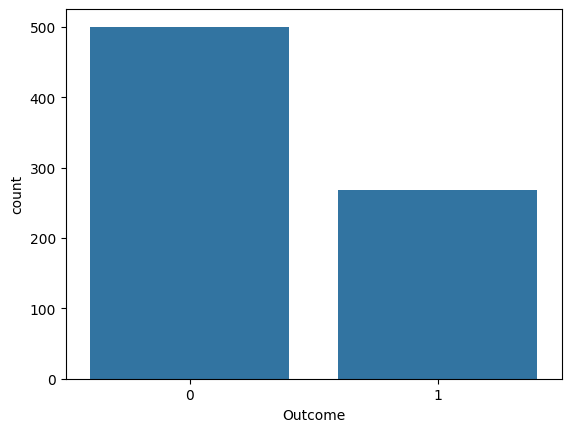

In [13]:
#Visualize
sns.countplot(x='Outcome', data=df)
plt.show()

**Distribution Analysis**


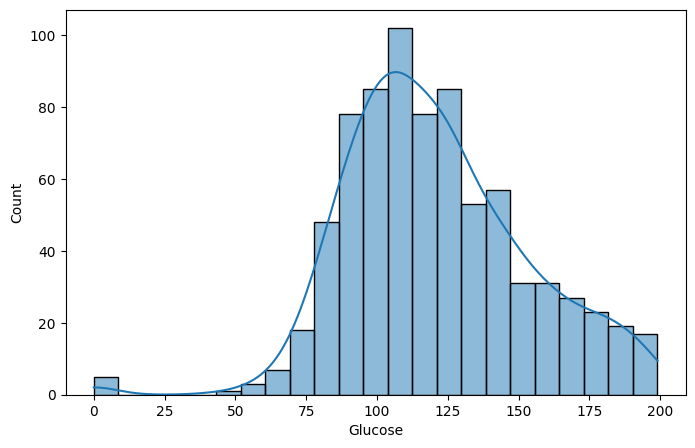

In [20]:
#Glucose Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Glucose'],kde=True)
plt.show()

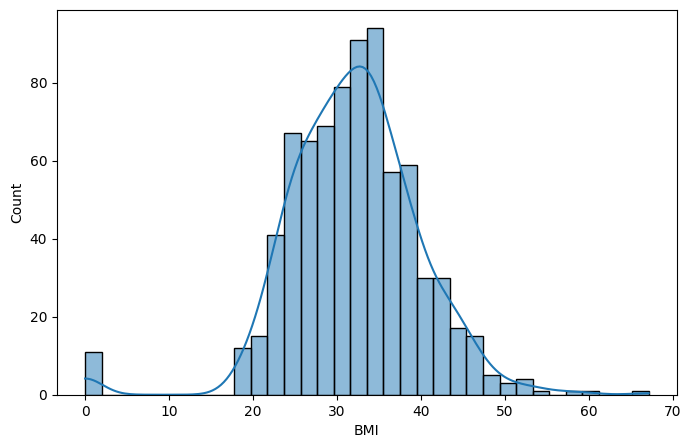

In [18]:
#BMI Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['BMI'], kde=True)
plt.show()

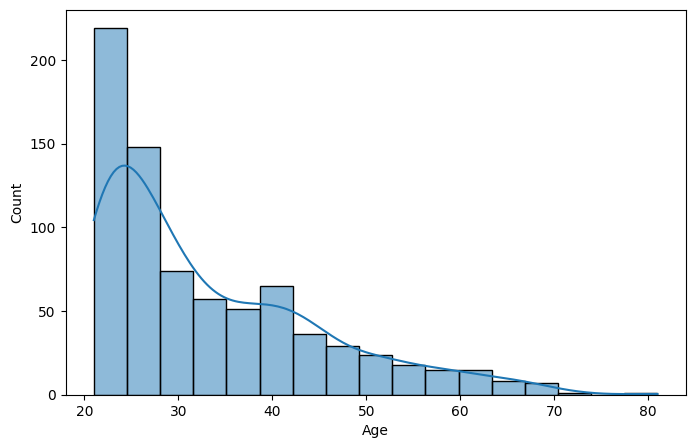

In [19]:
#Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], kde=True)
plt.show()

**Boxplots(Outlier Detection)**

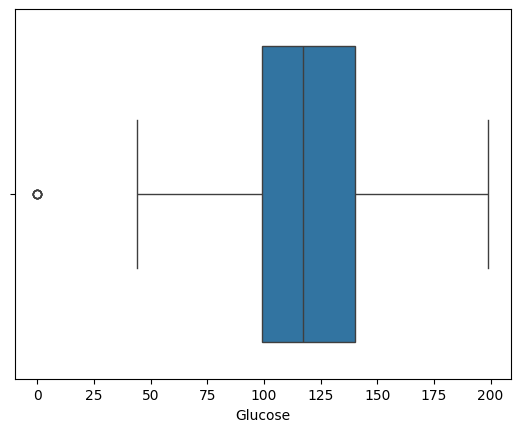

In [21]:
#GLucose
sns.boxplot(x=df['Glucose'])
plt.show()

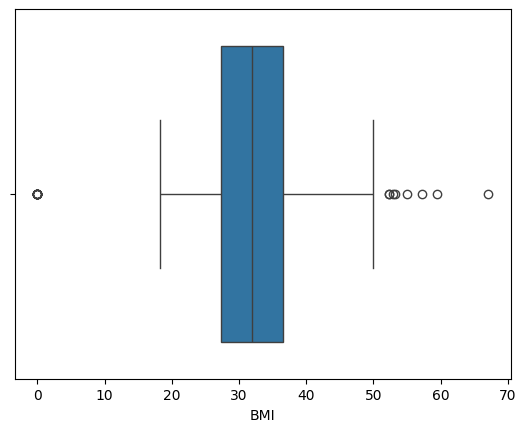

In [22]:
#BMI
sns.boxplot(x=df['BMI'])
plt.show()

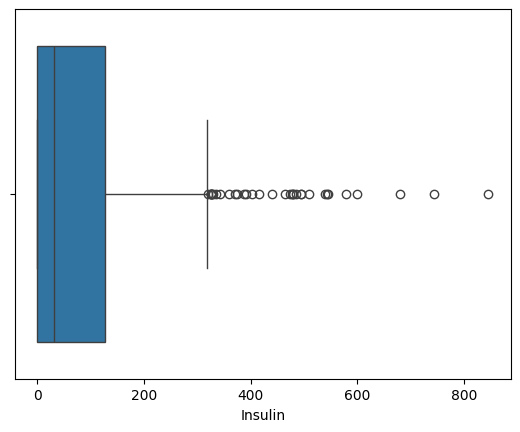

In [23]:
#Insulin
sns.boxplot(x=df['Insulin'])
plt.show()

**Correlation Analysis**

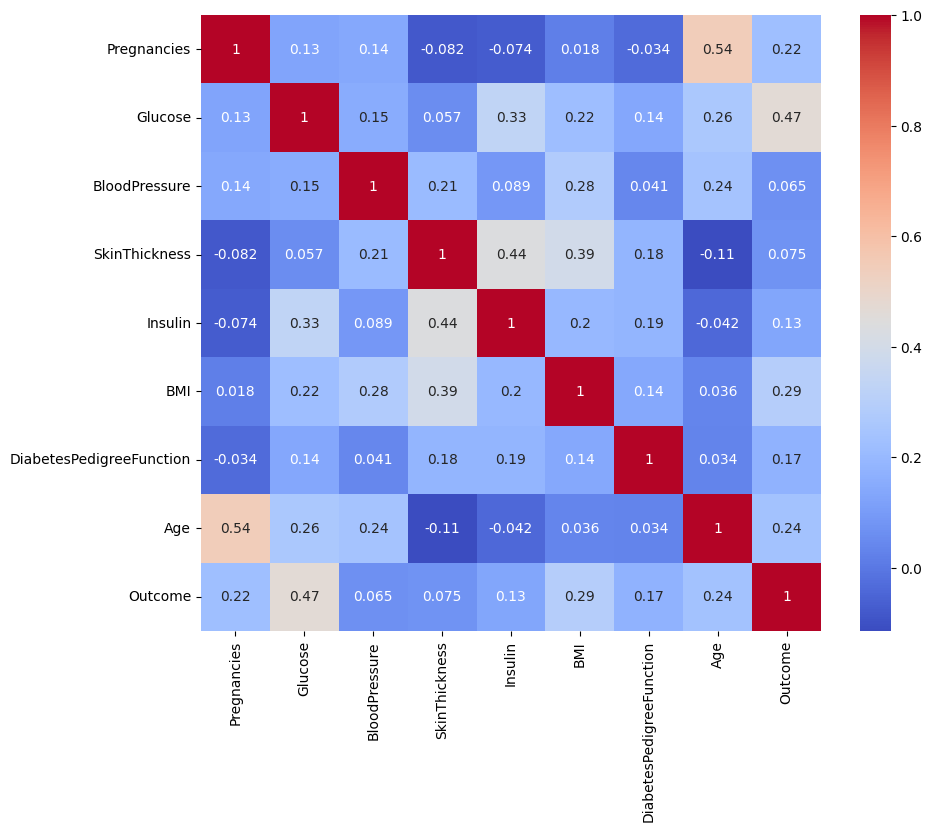

In [24]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

**Feature vs Outcome Analysis**

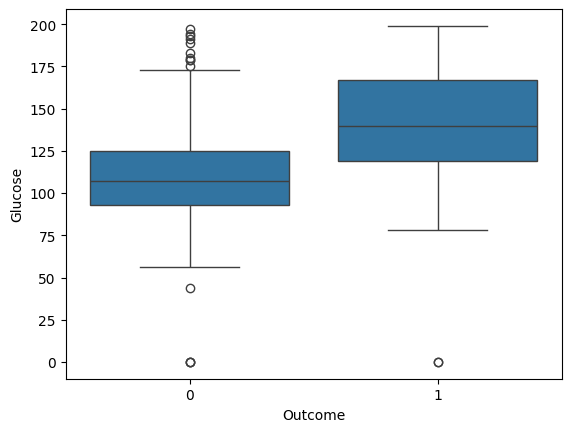

In [25]:
#Glucose VS Outcome
sns.boxplot(x='Outcome', y='Glucose', data=df)
plt.show()

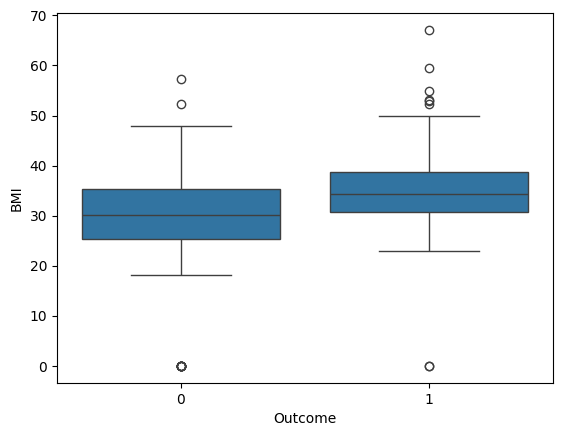

In [26]:
#BMI vs Outcome
sns.boxplot(x='Outcome', y='BMI', data=df)
plt.show()

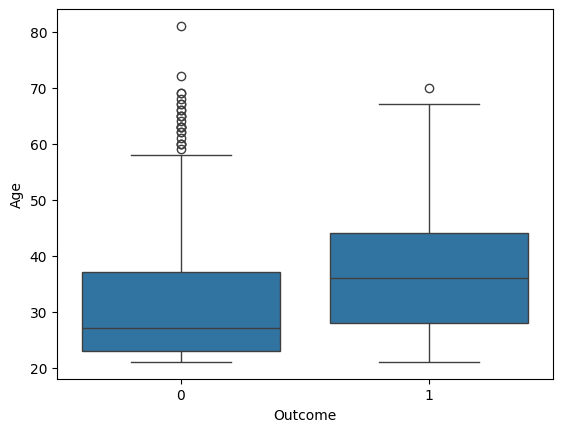

In [27]:
#Age VS Outcome
sns.boxplot(x='Outcome', y='Age', data=df)
plt.show()

**Visualize Relationships**

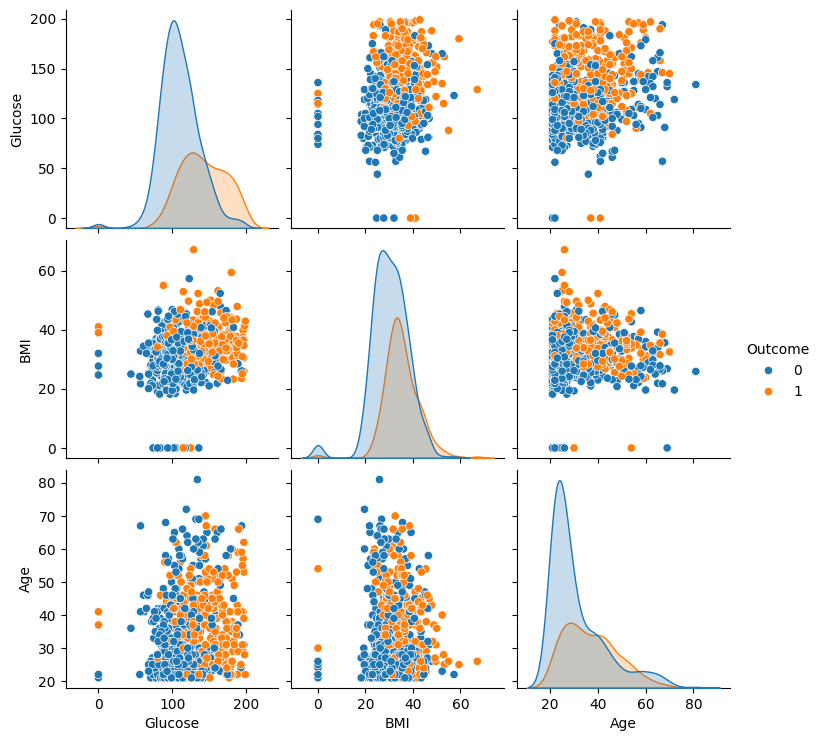

In [28]:
sns.pairplot(
    df[['Glucose','BMI','Age','Outcome']],
    hue='Outcome'
)

plt.show()

**EDA Conclusions**

1. Dataset contains 768 records and 8 predictor variables.

2. No null values are present.

3. Several medically impossible zero values exist in:
   - Glucose
   - BloodPressure
   - SkinThickness
   - Insulin
   - BMI

4. Glucose shows the strongest correlation with diabetes outcome.

5. Diabetic patients generally exhibit:
   - Higher glucose levels
   - Higher BMI
   - Higher age

6. Several features contain outliers, especially Insulin.

7. Data cleaning is required before model training.

**Data Cleaning and Feature Engineering**

In [29]:
# Features where 0 is medically invalid
invalid_zero_cols = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

# Count invalid zero values in each feature
for col in invalid_zero_cols:
    print(f"{col}: {(df[col] == 0).sum()} invalid values")

Glucose: 5 invalid values
BloodPressure: 35 invalid values
SkinThickness: 227 invalid values
Insulin: 374 invalid values
BMI: 11 invalid values


In [30]:
import numpy as np

# Replace invalid zero values with NaN
df[invalid_zero_cols] = df[invalid_zero_cols].replace(0, np.nan)

In [31]:
# Check number of missing values per feature
missing_values = df.isnull().sum()

print(missing_values)

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


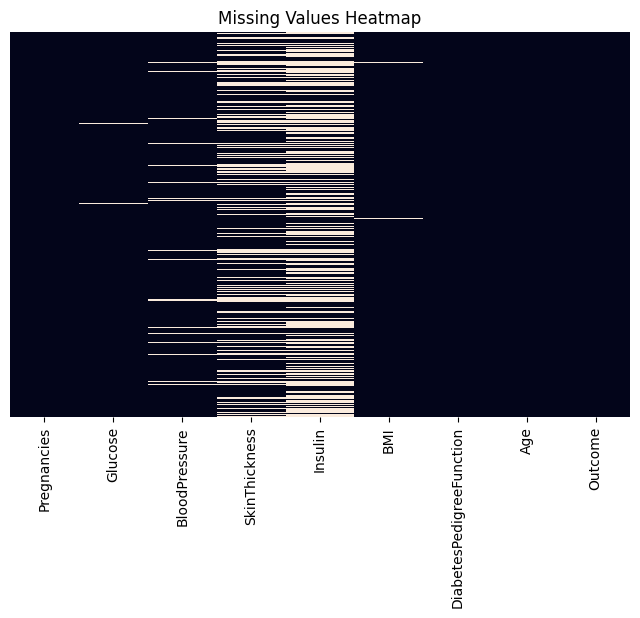

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values Heatmap")

plt.show()

In [34]:
#Impute Missing Values Using Median
#Why Median?

#Healthcare datasets often contain extreme values.

#Median is more robust than mean because it is less affected by outliers.
# Fill missing values using median imputation

for col in invalid_zero_cols:
    median_value = df[col].median()
    df[col].fillna(median_value, inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_28764\837285087.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_value, inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_28764\837285087.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when d

In [35]:
# Confirm dataset contains no missing values

print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


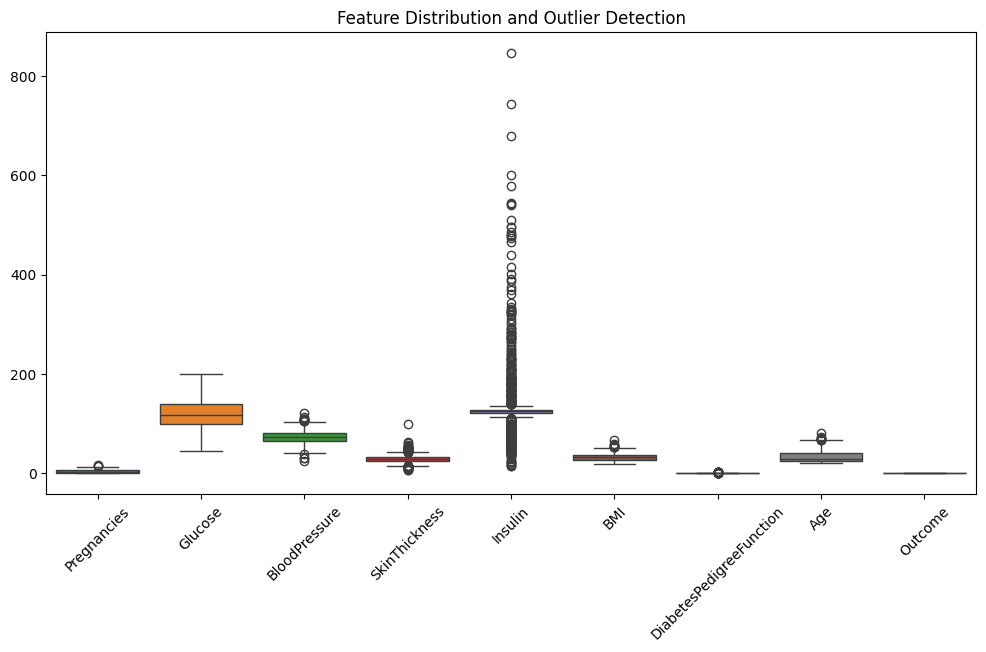

In [36]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df)

plt.xticks(rotation=45)

plt.title("Feature Distribution and Outlier Detection")

plt.show()

In [37]:
# Calculate quartiles

Q1 = df['BMI'].quantile(0.25)
Q3 = df['BMI'].quantile(0.75)

# Calculate Interquartile Range

IQR = Q3 - Q1

# Define lower and upper bounds

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers

bmi_outliers = df[
    (df['BMI'] < lower_bound) |
    (df['BMI'] > upper_bound)
]

print(f"Number of BMI outliers: {len(bmi_outliers)}")

Number of BMI outliers: 8


In [38]:
# Create BMI categories

df['BMI_Category'] = pd.cut(
    df['BMI'],
    bins=[0, 18.5, 25, 30, 100],
    labels=[
        'Underweight',
        'Normal',
        'Overweight',
        'Obese'
    ]
)

In [39]:
# Create age categories

df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[20, 30, 40, 50, 60, 100],
    labels=[
        '20-30',
        '30-40',
        '40-50',
        '50-60',
        '60+'
    ]
)

In [40]:
df[['BMI', 'BMI_Category', 'Age', 'Age_Group']].head()

,BMI,BMI_Category,Age,Age_Group
0,33.6,Obese,50,40-50
1,26.6,Overweight,31,30-40
2,23.3,Normal,32,30-40
3,28.1,Overweight,21,20-30
4,43.1,Obese,33,30-40


In [41]:
# Split features and target variable

X = df.drop('Outcome', axis=1)

y = df['Outcome']

In [42]:
# Keep only numerical features

X_numeric = X.select_dtypes(include=['int64', 'float64'])

In [43]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler

scaler = StandardScaler()

# Fit and transform data

X_scaled = scaler.fit_transform(X_numeric)

In [44]:
# Save cleaned dataset for modeling stage

df.to_csv(
    "../datasets/diabetes_clean.csv",
    index=False
)

Data Cleaning Summary

1. Identified medically invalid zero values in multiple clinical features.

2. Replaced invalid observations with NaN.

3. Applied median imputation to preserve dataset size while reducing sensitivity to outliers.

4. Investigated feature distributions and outliers using boxplots and the IQR method.

5. Engineered clinically meaningful features:
   - BMI Category
   - Age Group

6. Standardized numerical features to prepare data for machine learning algorithms.

7. Exported a cleaned dataset for the modeling phase.